# ECT on Matisse's "The Parakeet and the Mermaid"



 Here, we are going to give an example of using the ECT to classify the cutout shapes from Henri Matisse's 1952 ["The Parakeet and the Mermaid"](https://www.moma.org/audio/playlist/6/312).



 ![matisse.jpg](matisse.jpg)



In [1]:
# -----------------
# Standard imports
# -----------------
import numpy as np  # for arrays
import matplotlib.pyplot as plt  # for plotting
from sklearn.decomposition import PCA  # for PCA for normalization

from os import listdir  # for retrieving files from directory
from os.path import isfile, join  # for retrieving files from directory
from sklearn.manifold import MDS  # for MDS
import pandas as pd  # for loading in colors csv
import os
import zipfile

import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# The ECT packages we'll use
# ---------------------------
from ect import ECT, EmbeddedComplex  # for calculating ECTs
# Note: EmbeddedGraph is now unified into EmbeddedComplex
# For backward compatibility, you can still use:
# from ect import EmbeddedGraph

# Simple data paths
data_dir = "outlines/"
colors_path = "colors.csv"

# Ensure outlines are available when running under Sphinx/CI
if not os.path.isdir(data_dir):
    zip_path = "outlines.zip"
    if os.path.isfile(zip_path):
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(".")
    else:
        raise FileNotFoundError(
            "Could not find 'outlines/' directory or 'outlines.zip'. "
            "Please download the Matisse outlines and place them next to this notebook."
        )

file_names = [
    f for f in listdir(data_dir) if isfile(join(data_dir, f)) and f[-4:] == ".txt"
]
file_names.sort()
print(f"There are {len(file_names)} files in the directory")

There are 150 files in the directory


 We've taken care of the preprocessing in advance by extracting out the shapes from the image.  You can download these outlines here: [outlines.zip](outlines.zip).



 <img src="matisse_numbered.jpg" alt="Matisse Numbered" style="width:50%;">

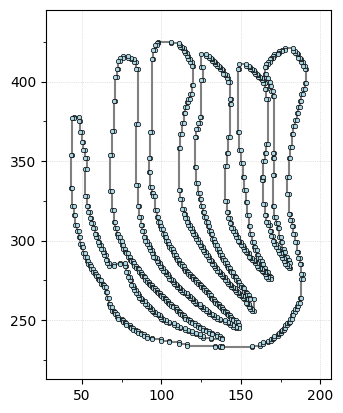

In [2]:
i = 3
shape = np.loadtxt(data_dir + file_names[i])
# shape = normalize(shape)
G = EmbeddedComplex()  # Using the unified EmbeddedComplex class
G.add_cycle(shape)
G.plot(with_labels=False, node_size=10);

 We're going to align the leaf using the PCA coordinates, min-max center, and scale it to fit in a ball of radius 1 for ease of comparisons.

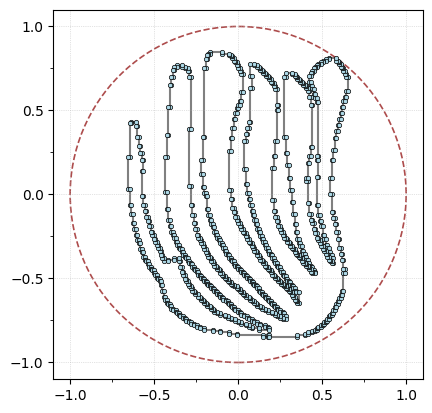

In [3]:

G.transform_coordinates(projection_type="pca")  # project with PCA
G.scale_coordinates(1)  # scale to radius 1
G.plot(with_labels=False, node_size=10, bounding_circle=True);

 And then we can compute the ECT of this leaf.

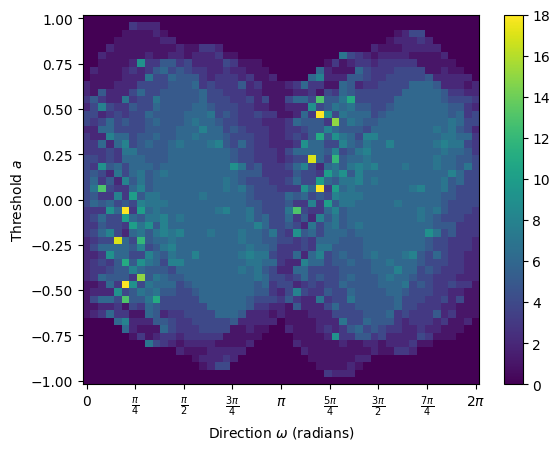

In [4]:
num_dirs = 50  # set number of directional axes
num_thresh = 50  # set number of thresholds each axis

myect = ECT(num_dirs=num_dirs, num_thresh=num_thresh);  # intiate ECT
result = myect.calculate(G);  # calculate ECT on embedded graph

result.plot();  # plot ECT

 Let's just make a data loader with all of this for ease in a bit.

In [5]:
def matisse_ect(filename, ect):
    shape = np.loadtxt(data_dir + filename)
    G = EmbeddedComplex()  # Using the unified EmbeddedComplex class  
    G.add_cycle(shape)
    G.transform_coordinates(projection_type="pca")
    G.scale_coordinates(1)
    result = ect.calculate(G)
    return result

 And now we can load in all the outlines, compute their ECT and store it in a 3D array.

In [6]:
num_dirs = 50  # set number of directional axes
num_thresh = 50  # set number of thresholds each axis

ect_arr = np.zeros((len(file_names), num_dirs, num_thresh))
ect_results = []
myect = ECT(num_dirs=num_dirs, num_thresh=num_thresh, bound_radius=1)

for i in range(len(file_names)):  # for each leaf
    res = matisse_ect(file_names[i], myect)
    ect_results.append(res)
    ect_arr[i, :, :] = res

 Here, we are just going to compute the distance between two ECTs which uses the Frobenius distance by default.

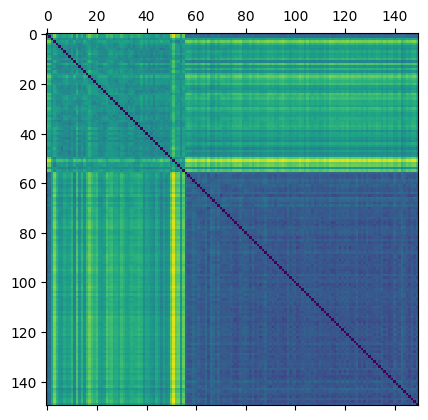

In [7]:
D = ect_results[0].dist_matrix(ect_results)
plt.matshow(D);

 For visualization purposes, we can project this data into 2D using Multi Dimensional Scaling (MDS). Here we plot each figure at the MDS coordinates.

In [8]:
n_components = 2  # select number of components
mds = MDS(
    n_components=n_components,  # initialize MDS
    dissimilarity="precomputed",  # we have precomputed the distance matrix
    normalized_stress="auto",
    random_state=5,  # select random state for reproducibility
)
MDS_scores = mds.fit_transform(D)  # get MDS scores

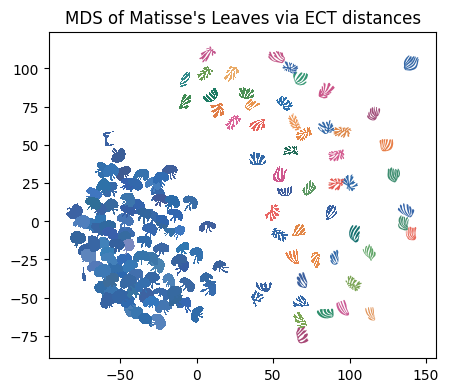

In [9]:
# read in color hexcodes
col_df = pd.read_csv(colors_path, header=None)

scale_val = 6  # set scale value
plt.figure(figsize=(5, 5))  # set figure dimensions

for i in range(len(file_names)):  # for each leaf
    shape = np.loadtxt(data_dir + file_names[i])  # get the current shape
    shape = shape - np.mean(shape, axis=0)  # zero center shape
    shape = (
        scale_val * shape / max(np.linalg.norm(shape, axis=1))
    )  # scale to radius 1 then mult by scale_val

    trans_sh = shape + MDS_scores[i]  # translate shape to MDS position

    plt.fill(trans_sh[:, 0], trans_sh[:, 1], c=col_df[0][i], lw=0)  # plot shape
    plt.gca().set_aspect("equal")

plt.title("MDS of Matisse's Leaves via ECT distances");

## Acknowledgements



 This notebook was written by [Liz Munch](https://elizabethmunch.com/) and improved by [Yemeen Ayub](https://yemeen.com/) based on [original code](https://github.com/DanChitwood/matisse_test) from [Dan Chitwood](https://www.canr.msu.edu/people/dr_dan_chitwood).